## The CoffeeViz Notebook

![Assimila Logo](img/assimila.png) ![CABI Logo](img/cabi.png)

Please click on `Kernel/Restart & Clear Output` to start using the Notebook.

In [8]:
import os
import numpy as np
import xarray as xr
import fsspec
import numpy as np
import pandas as pd
import folium
from folium.raster_layers import ImageOverlay
from folium import plugins
from branca.colormap import LinearColormap
from datetime import datetime, timedelta
import matplotlib.cm as cm
import matplotlib
import calendar
from datetime import datetime, timedelta
from ipywidgets import HTML, Text, Button, VBox, Output

def extract_data_from_netcdfs(netcdf_files, variable_name, lat, lon):
    """
    Extract data for a specific latitude and longitude location from multiple NetCDF files.

    Parameters:
        netcdf_files (list): List of paths to NetCDF files.
        variable_name (str): Name of the variable to extract from the NetCDF files.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.

    Returns:
        dict: A dictionary where keys are NetCDF file names and values are the extracted data.
    """
    extracted_data = {}

    for netcdf_file in netcdf_files:
        # Open the NetCDF file
        # ds = xr.open_dataset(netcdf_file)
        with fsspec.open(netcdf_file, mode="rb") as file:
            ds = xr.load_dataset(file, engine='h5netcdf')

        # Ensure the variable exists in the file
        if variable_name not in ds:
            print(f"Variable '{variable_name}' not found in {netcdf_file}. Skipping.")
            continue

        # Find the nearest point to the specified latitude and longitude
        try:
            data_point = ds[variable_name].sel(latitude=lat, longitude=lon, method='nearest')
            julian_day = data_point.values

            # Convert Julian day to a calendar date
            start_date = datetime(2024, 1, 1)
            calendar_date = start_date + timedelta(days=int(julian_day) - 1)

            extracted_data[os.path.basename(netcdf_file)] = calendar_date.strftime('%Y-%m-%d')

        except KeyError as e:
            print(f"Error extracting data from {netcdf_file}: {e}")
            continue

    return extracted_data

def date_to_julian_day(date_string):
    """
    Convert an ISO 8601 date string into a Julian day.

    Parameters:
        date_string (str): The date string in ISO 8601 format (e.g., '2024-03-01T00:00:00.000000000').

    Returns:
        int: The Julian day of the year.
    """
    # Parse the date string into a datetime object
    date = datetime.strptime(date_string.split('T')[0], '%Y-%m-%d')
    
    # Calculate the Julian day
    julian_day = date.timetuple().tm_yday
    
    return julian_day

def julian_to_date(julian_day, start_year=2024):
    """
    Convert Julian day to a calendar date.
    """
    start_date = datetime(start_year, 1, 1)  # Start of the year
    return start_date + timedelta(days=julian_day - 1)

def display_netcdfs_on_map(netcdf_files, variable_name, colormap_name='viridis', opacity=1.0):
    """
    Display multiple NetCDF files on a single folium map.

    Parameters:
        netcdf_files (list): List of paths to NetCDF files.
        variable_name (str): Name of the variable to extract from the NetCDF files.
        colormap_name (str): Name of the matplotlib colormap to use (default: 'viridis').
        opacity (float): Opacity of the overlay layers (default: 0.7).

    Returns:
        folium.Map: A folium map with all NetCDF layers added.
    """
    
    # Loop through each NetCDF file
    for i, netcdf_file in enumerate(netcdf_files):
        # Load the NetCDF file
        with fsspec.open(netcdf_file, mode="rb") as file:
            d = xr.load_dataset(file, engine='h5netcdf')

        # Extract the data and coordinates
        start_date_doy = date_to_julian_day(d.attrs['temperature_data_start_date'])
        data = d[variable_name].values + start_date_doy

        # Mask NaN and zero values in the data
        masked_data = np.ma.masked_where((data == 0) | np.isnan(data), data)

        # Get the min and max values of the data for the colormap
        tta_min, tta_max = np.nanmin(masked_data), np.nanmax(masked_data)

        lat = d['latitude'].values
        lon = d['longitude'].values

        # Get the bounds of the data
        lat_min, lat_max = lat.min(), lat.max()
        lon_min, lon_max = lon.min(), lon.max()

        # Calculate the centroid of the image
        centroid_lat = (lat_min + lat_max) / 2
        centroid_lon = (lon_min + lon_max) / 2

        # Set the map center on the first iteration
        if i == 0:
            map_center_lat = centroid_lat
            map_center_lon = centroid_lon
            m = folium.Map(location=[map_center_lat, map_center_lon], zoom_start=6)
        
        # Normalize the data to [0, 1] based on tta_min and tta_max
        normalized_data = (masked_data - tta_min) / (tta_max - tta_min)

        # Apply the colormap to the normalized data
        colormap = matplotlib.colormaps[colormap_name]
        rgba_image = colormap(normalized_data)  # This gives an RGBA image

        # Convert RGBA
        rgb_image = (rgba_image * 255).astype(np.uint8)  # Scale to 0-255 for RGB

        # Add the raster data as an overlay
        img = ImageOverlay(
            image=rgb_image,
            bounds=[[lat_min, lon_min], [lat_max, lon_max]],
            opacity=opacity,
            interactive=True,
            cross_origin=False,
            zindex=1,
            name=os.path.basename(netcdf_file),
            control=True,
            show=False
        )
        # Add the image overlay to the map
        img.add_to(m)

        if i == 0:
            # Show only the first layer by default
            img.show = True

            # Add a colorbar using branca.colormap
            branca_colormap = LinearColormap(
                colors=[colormap(i) for i in np.linspace(0, 1, 256)],
                vmin=tta_min,
                vmax=tta_max
            )
            
            branca_colormap.caption = "Days to threshold (DOY)"

            # Add the colormap to the map
            branca_colormap.add_to(m)        

    # Add the OpenTopoMap tile layer
    folium.TileLayer(
        tiles="https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png",
        attr="Map data: &copy; <a href='https://www.opentopomap.org/'>OpenTopoMap</a> contributors",
        name="OpenTopoMap",
        max_zoom=17
    ).add_to(m)

    # Add the ESRI World Imagery tile layer
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Tiles &copy; Esri &mdash; Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community",
        name="ESRI World Imagery",
        max_zoom=20
    ).add_to(m)

    plugins.Fullscreen(
        position="topright",
        title="Expand me",
        title_cancel="Exit me",
        force_separate_button=True,
    ).add_to(m)

    formatter = "function(num) {return L.Util.formatNum(num, 3) + ' &deg; ';};"

    plugins.MousePosition(
        position="bottomright",
        separator=" | ",
        empty_string="NaN",
        lng_first=True,
        num_digits=20,
        prefix="Coordinates:",
        lat_formatter=formatter,
        lng_formatter=formatter,
    ).add_to(m)

    folium.LatLngPopup().add_to(m)

    # Add a layer control to toggle layers
    folium.LayerControl().add_to(m)

    return m

def generate_colored_date_ranges_and_legend(phen_df):
    """
    Generate colored date ranges and a legend dictionary from the phen_df DataFrame.

    Parameters:
        phen_df (pd.DataFrame): DataFrame containing phenology data with columns ['File', 'Days to Threshold'].

    Returns:
        tuple: A tuple containing:
            - colored_date_ranges (list): List of tuples with (start_date, end_date, color).
            - legend (dict): Dictionary mapping colors to descriptions.
    """
    # Define stage-to-color mapping
    stage_colors = {
        "flowering": "red",
        "pinhead": "green",
        "expansion": "blue",
        "vulnerable": "yellow",
        "hardening": "orange",
        "harvest": "purple"
    }

    # Initialize the legend
    legend = {color: f"{stage.capitalize()} stage" for stage, color in stage_colors.items()}

    # Initialize the colored_date_ranges
    colored_date_ranges = []

    # Iterate through each stage and find the corresponding start and end dates
    for stage, color in stage_colors.items():
        # Find the start and end files for the current stage
        start_file = phen_df[phen_df["File"].str.contains(f"{stage}_start", case=False)]
        end_file = phen_df[phen_df["File"].str.contains(f"{stage}_end", case=False)]

        if not start_file.empty and not end_file.empty:
            # Extract the start and end dates
            start_date = datetime.strptime(start_file.iloc[0]["Days to Threshold"], "%Y-%m-%d")
            end_date = datetime.strptime(end_file.iloc[0]["Days to Threshold"], "%Y-%m-%d")

            # Add the date range to the colored_date_ranges
            colored_date_ranges.append((
                start_date.strftime("%Y-%m-%d"),
                end_date.strftime("%Y-%m-%d"),
                color
            ))

    return colored_date_ranges, legend

def create_colored_calendar_range_with_legend(year, months, colored_date_ranges, legend):
    """
    Create a calendar widget for multiple months with specific date ranges colored and a legend.

    Parameters:
        year (int): The year for the calendar.
        months (list): List of months (integers) to display.
        colored_date_ranges (list): A list of tuples where each tuple contains:
            - start_date (str): Start date of the range in 'YYYY-MM-DD' format.
            - end_date (str): End date of the range in 'YYYY-MM-DD' format.
            - color (str): Color to apply to the range.
        legend (dict): A dictionary where keys are colors and values are descriptions.

    Returns:
        ipywidgets.VBox: A widget displaying the calendar with a legend.
    """
    from ipywidgets import GridspecLayout

    # Parse the colored date ranges into a dictionary of dates and colors
    colored_dates = {}
    for start_date, end_date, color in colored_date_ranges:
        start = datetime.strptime(start_date, '%Y-%m-%d')
        end = datetime.strptime(end_date, '%Y-%m-%d')
        current = start
        while current <= end:
            colored_dates[current.strftime('%Y-%m-%d')] = color
            current += timedelta(days=1)

    # Create HTML for each month
    month_html_list = []
    for month in months:
        # Create a calendar object
        cal = calendar.Calendar()

        # Start building the HTML for the calendar
        html = '<table style="border-collapse: collapse; width: 100%; margin-bottom: 20px;">'
        html += '<tr><th colspan="7" style="text-align: center; font-size: 20px;">'
        html += f'{calendar.month_name[month]} {year}</th></tr>'
        html += '<tr>'
        for day in calendar.day_name:
            html += f'<th style="border: 1px solid black; padding: 5px;">{day[:2]}</th>'
        html += '</tr>'

        # Add the days of the month
        for week in cal.monthdayscalendar(year, month):
            html += '<tr>'
            for day in week:
                if day == 0:
                    # Empty cell for days outside the current month
                    html += '<td style="border: 1px solid black; padding: 5px;"></td>'
                else:
                    # Format the date as YYYY-MM-DD
                    date_str = f'{year}-{month:02d}-{day:02d}'
                    # Check if the date is in the colored_dates dictionary
                    color = colored_dates.get(date_str, 'white')
                    html += f'<td style="border: 1px solid black; padding: 5px; background-color: {color}; text-align: center;">{day}</td>'
            html += '</tr>'
        html += '</table>'

        # Append the month's HTML to the list
        month_html_list.append(HTML(html))

    # Create the legend HTML
    legend_html = '<div style="margin-top: 20px;"><strong>Legend:</strong><ul>'
    for color, description in legend.items():
        legend_html += f'<li style="margin-bottom: 5px;"><span style="display: inline-block; width: 20px; height: 20px; background-color: {color}; margin-right: 10px; border: 1px solid black;"></span>{description}</li>'
    legend_html += '</ul></div>'

    # Arrange the months in a 3-row, 4-column layout
    grid = GridspecLayout(3, 4, height='auto')
    for i, month_html in enumerate(month_html_list):
        row = i // 4
        col = i % 4
        grid[row, col] = month_html

    # Return the calendar and legend as a VBox
    return VBox([grid, HTML(legend_html)])

# Time to Action data
dataDir = 'https://storage.googleapis.com/clearsky/TIS/thermal_thresholds'
tta_files = ['TTA_window1_2024.nc', 'TTA_window2_2024.nc', 'TTA_window3_2024.nc']
tta_files = [os.path.join(dataDir, f) for f in tta_files]

# Phenology stages
dataDir = 'https://storage.googleapis.com/clearsky/TIS/thermal_thresholds'

phen_files = ['coffee_phen_stage_01_flowering_start_2024.nc', 'coffee_phen_stage_01_flowering_end_2024.nc', 
              'coffee_phen_stage_02_pinhead_start_2024.nc', 'coffee_phen_stage_02_pinhead_end_2024.nc',
              'coffee_phen_stage_03_expansion_start_2024.nc', 'coffee_phen_stage_03_expansion_end_2024.nc',
              'coffee_phen_stage_04_vulnerable_start_2024.nc', 'coffee_phen_stage_04_vulnerable_end_2024.nc',
              'coffee_phen_stage_05_hardening_start_2024.nc', 'coffee_phen_stage_05_hardening_end_2024.nc', 
              'coffee_phen_stage_06_harvest_start_2024.nc', 'coffee_phen_stage_06_harvest_end_2024.nc']
phen_files = [os.path.join(dataDir, f) for f in phen_files]

## Data extraction
For a selected latitude and longitude point extract the data. You can get the coordinate by clicking on the maps.

In [10]:
# Create widgets
lat_input = Text(description='Latitude:', placeholder='Enter latitude', value='0.35')
lon_input = Text(description='Longitude:', placeholder='Enter longitude', value='37.90')
extract_button = Button(description='Extract data', button_style='success')
output = Output()
months = np.arange(1, 13)

# Define the button click event
def on_extract_button_click(b):
    with output:
        output.clear_output()
        try:
            # Get latitude and longitude values
            lat = float(lat_input.value)
            lon = float(lon_input.value)

            # Extract data for Time to Action and Phenology stages
            tta_data = extract_data_from_netcdfs(tta_files, 'days_to_threshold', lat, lon)
            phen_data = extract_data_from_netcdfs(phen_files, 'days_to_threshold', lat, lon)

            # Combine results into a DataFrame
            tta_df = pd.DataFrame(list(tta_data.items()), columns=['File', 'Days to Threshold'])
            phen_df = pd.DataFrame(list(phen_data.items()), columns=['File', 'Days to Threshold'])
            
            # Generate the colored_date_ranges and legend from phen_df
            colored_date_ranges, legend = generate_colored_date_ranges_and_legend(phen_df)
            
            # Create the calendar widget
            calendar_widget = create_colored_calendar_range_with_legend(2024, months, colored_date_ranges, legend)
            
            # Display results
            print("### Time to Action Data")
            display(tta_df)
            print("### Phenology Stages Data")
            display(phen_df)
            print("### Colored Calendar with Phenology Stages")
            display(calendar_widget)
        except ValueError:
            print("Please enter valid numeric values for latitude and longitude.")

# Attach the event to the button
extract_button.on_click(on_extract_button_click)

# Display the widgets and output
VBox([lat_input, lon_input, extract_button, output])

## Time to Act
The Time to Act values are three "action windows" when action should be taken against coffee berry borer pests.


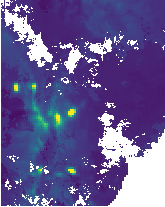
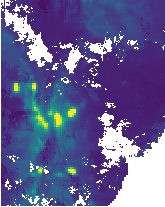
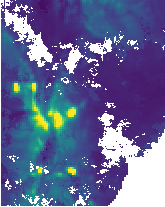

In [3]:
# Display the map
variable_name='days_to_threshold'
m1 = display_netcdfs_on_map(tta_files, variable_name=variable_name, opacity=0.7)
m1

## Phenology stages
The phenology values represent when to expect coffee plants to reach various phenological stages based on environmental conditions.

These stages are: flowering, pinhead development, berry expansion, vulnerable berries (>0.6cm), berry hardening and ripening and harvest. 


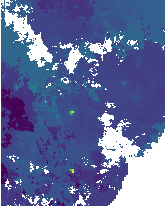
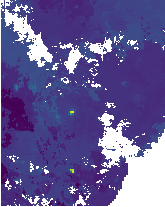
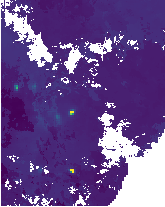
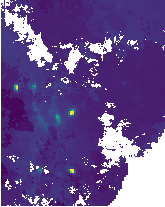
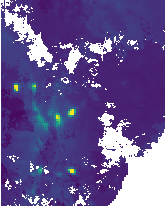
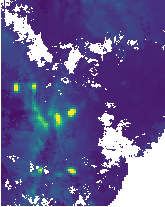
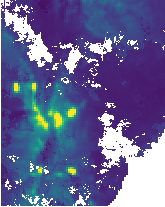
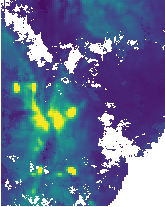
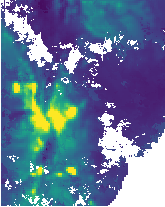
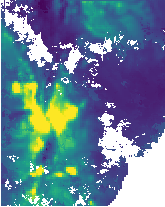
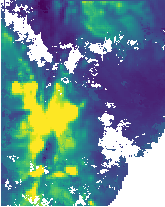
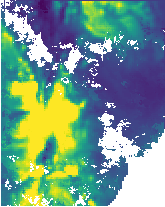

In [4]:
# Display the map
m2 = display_netcdfs_on_map(phen_files, variable_name='days_to_threshold')
m2